# Étude de méthodes d'optimisation stochastique : Régression Logistique

**Auteur** : Hamza KALIM

**Résumé** : Implémentation et comparaison de méthodes avancées (SGD, Momentum, Adam) visant à minimiser une perte logistique.

## Analyse 1: Understanding the Convergence of SGD

Firstly, we study optimization dynamics for a regularized logistic regression problem solved by stochastic gradient descent (SGD).

We want to understand how the variance of the stochastic gradient estimate impacts its convergence, and how to improve it. To do that, we focus on the effect of two hyperparameters:
 1. batch size
 2. learning-rate

We will see how a fixed batch size impacts the convergence and show the advantages of an increasing batch size. In the same way, we will study the effect of decreasing learning-rates.


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Number of epochs, use larger value for more accurate results
EPOCHS = 750    

# Hyperparameters
lr0 = 1e-3          # Initial learning rate
LAMBDA_REG = 1e-4      # L2 regularization strength

#### Creation of the synthetic dataset

We generate features $X \in \mathbb{R}^{m \times n}$ with logarithmically spaced scaling
(ranging from 1 to 1000 across dimensions). This creates strong anisotropy that makes
optimization behavior more interesting and closer to realistic ill-conditioned problems.

In [19]:
def make_synthetic_logistic(m=5000, n=40, seed=0):
    """Generate ill-conditioned logistic regression dataset."""
    rng = np.random.default_rng(seed)

    # Features with logarithmically spaced scaling (creates anisotropy)
    X = rng.normal(size=(m, n))
    scales = np.logspace(0, 3, n)   # Scale ranges from 1 to 10000
    X = X * scales

    # Generate binary labels from logistic model
    #theta_true = rng.normal(size=n)
    theta_true = 0.1 * np.ones(n)
    logits = X @ theta_true
    p = 1.0 / (1.0 + np.exp(-logits))
    y = rng.binomial(1, p)

    return X.astype(np.float64), y.astype(np.int32), theta_true


X, y, theta_true = make_synthetic_logistic(m=4000, n=50, seed=0)
print("X shape:", X.shape, "| y shape:", y.shape)
print("y mean (class balance):", y.mean())

X shape: (4000, 50) | y shape: (4000,)
y mean (class balance): 0.50025


#### Regularized logistic regression minimization problem

We minimize:
$$f(\theta) = \frac{1}{n}\sum_{i=1}^n \ell( x_i^T \theta, y_i) + \frac{\lambda}{2}\|\theta\|^2,$$
where $\theta$ are unknown parameterms and $\ell$ is the logistic loss:
$$
\ell(z, y)
  = -\, y \log z
    - (1 - y)\log(1 - z)
$$
and $\lambda > 0$ is a regularization parameter. 

We implement
the  sigmoid function, the logistic loss, its gradient and its Hessian.


In [20]:
from numpy._core.numeric import zeros_like


def sigmoid(z):
    """Numerically stable sigmoid to avoid overflow."""
    z = z.astype(np.float64, copy=False)
    out = np.empty_like(z, dtype=np.float64)
    # Handle positive and negative values separately for stability
    pos = (z >= 0)
    neg = ~pos
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[neg])
    out[neg] = ez / (1.0 + ez)
    return out

def logloss(theta, X, y, lambda_reg=1e-4):
    """Logistic loss with L2 regularization."""
    z = X @ theta
    p = sigmoid(z)
    eps = 1e-12
    # Compute average log loss and add L2 penalty
    loss = 0.0
    loss = np.mean(-y * np.log(p + eps) - (1 - y) * np.log(1 - p + eps)) + (lambda_reg / 2.0) * np.sum(theta**2)
    return float(loss)

def grad_logloss(theta, X, y, lambda_reg=1e-4):
    """Gradient of logistic loss (used by SGD)."""
    n = X.shape[0]
    z = X @ theta   
    p = sigmoid(z)

    # Compute gradient of log loss and add L2 penalty   
    grad = zeros_like(theta, dtype=np.float64)
    
    grad = (X.T @ (p - y)) / n + lambda_reg * theta
    return grad.astype(np.float64)

## Note, damping is added to ensure Hessian is positive definite for Newton's method
def hess_logloss_full(theta, X, y, lambda_reg=1e-4, damping=1e-8):
    n, d = X.shape
    z = X @ theta
    p = sigmoid(z)

    # Compute Hessian of log loss and add L2 penalty
    H = np.zeros((d,d), dtype=np.float64)

    H = (X.T * (p*(1-p))) @ X / n + lambda_reg * np.eye(d) + damping * np.eye(d)
    return H


#### Reference optimum $f(\theta^*)$
We will measure progress in the optimization through suboptimality:  $f(\theta_k) - f(\theta^*)$, where $\theta_k$ and  $\theta^*$ denote the model parameters at iteration $k$ and the solution, respectivelly.
A reliable reference value $f(\theta^*)$ can be computed via Newton's method. To save computational time we then utilize a precomputed value.

In [21]:
# Precompute optimal loss value for suboptimality measurements
def newton_solve_opt(X, y, lambda_reg=1e-4, tol=1e-10, max_iter=5000):
    """Compute optimal value via Newton's method (expensive, for reference)."""
    d = X.shape[1]
    theta = np.zeros(d)

    for it in range(max_iter):
        g = grad_logloss(theta, X, y, lambda_reg)
        ng = np.linalg.norm(g)
        if ng < tol:
            print(f"[Newton] Converged in {it} iterations | ||g||={ng:.2e}")
            break

        # Implement Newton's method update
        # Newton step: theta = theta - \alpha H^{-1} * g
        H = hess_logloss_full(theta, X, y, lambda_reg)
        theta = theta - np.linalg.solve(H, g)

    f_star = logloss(theta, X, y, lambda_reg)
    print(f"[Newton] f* = {f_star:.12e}")
    return theta, f_star


# Uncomment to recompute f_opt (slow; needed if data or regularization changes)
theta_star, f_opt = newton_solve_opt(X, y, lambda_reg=LAMBDA_REG)

[Newton] Converged in 21 iterations | ||g||=6.42e-16
[Newton] f* = 1.394276343790e-04


#### SGD runner (fixed batch size)

We implement full-epoch SGD with shuffling, mini-batch updates, and per-epoch tracking of the loss, suboptimality, and direction variance.

Direction variance is a measure of SGD noise. Within each epoch, SGD produces a sequence of update directions $d_1, \dots, d_M$ (one per mini-batch). We quantify the variability of the mini-batch directions using the following dimensionless indicator:

$$
\text{dir}_{\text{var}} = \frac{\mathbb{E}\|d_i - \bar{d}\|^2}{\|\bar{d}\|^2}, 
\quad 
\bar{d} = \mathbb{E}[d_i],
$$

where the index $i$ denotes the $i$-th mini-batch.

In [22]:
def run_sgd(
    X, y, lambda_reg=LAMBDA_REG,
    epochs=300, batch_size=8,
    lr0=1e-3, scheduler=None,
    seed=0, f_opt=None
):
    n, d = X.shape
    rng = np.random.default_rng(seed)
    theta = np.zeros(d)

    hist_loss, hist_subopt, hist_var, hist_epoch = [], [], [], []

    for ep in range(epochs):
        lr = lr0 if scheduler is None else scheduler(ep, lr0)

        idx = rng.permutation(n)
        Xs, ys = X[idx], y[idx]

        dirs = []
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            # Implement SGD search direction
            d = zeros_like(theta, dtype=np.float64)
            g = grad_logloss(theta, Xs[start:end], ys[start:end], lambda_reg)
            d =  -lr * g
            
            dirs.append(d)
            theta = theta + d

        f = logloss(theta, X, y, lambda_reg)
        hist_loss.append(f)
        hist_subopt.append(f - f_opt)
        hist_epoch.append(ep)

        D = np.stack(dirs, axis=0)

        # Now, we compute variance of SGD directions relative to mean direction
        mean_d = D.mean(axis=0)
        diff = D - mean_d
        num = np.mean(np.sum(diff * diff, axis=1))
        denom = np.linalg.norm(mean_d) ** 2 + 1e-12
        var_dir = num / denom

        hist_var.append(var_dir)

    return {
        "epoch": np.array(hist_epoch),
        "loss": np.array(hist_loss),
        "subopt": np.array(hist_subopt),
        "dir_var": np.array(hist_var),
    }

###  Study the effect of the batch size on convergence of SGD
We run SGD with constant batch sizes 4, 16 and 1024. Here the learning rate is a fixed small constant.

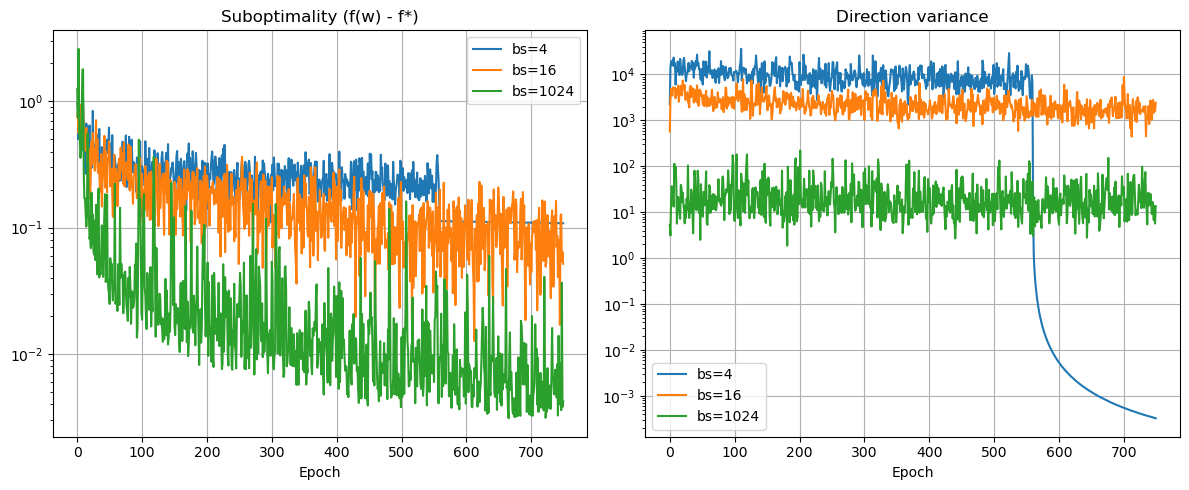

In [23]:
bs_list = [4, 16, 1024]
histories_B = {}

for bs in bs_list:
    h = run_sgd(
        X, y, lambda_reg=LAMBDA_REG,
        epochs=EPOCHS, batch_size=bs,
        lr0=lr0, scheduler=None,
        seed=0, f_opt=f_opt
    )
    histories_B[bs] = h

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
for bs in bs_list:
    plt.semilogy(histories_B[bs]["epoch"], histories_B[bs]["subopt"], label=f"bs={bs}")
plt.title("Suboptimality (f(w) - f*)")
plt.xlabel("Epoch")
plt.grid(True); plt.legend()

plt.subplot(1,2,2)
for bs in bs_list:
    plt.semilogy(histories_B[bs]["epoch"], histories_B[bs]["dir_var"], label=f"bs={bs}")
plt.title("Direction variance")
plt.xlabel("Epoch")
plt.grid(True); plt.legend()

plt.tight_layout()
plt.show()

### Questions 1.1:
1. Explain the relationship between batch size and direction variance shown in the plots. Why does increasing the batch size from 4 to 1024 reduce the variance of SGD update directions? What is the cost of this reduction?

2. From the suboptimality curves in Ex1.1, which batch size reaches the best final solution and why?

1) On observe que lorsque la taille du batch augmente, la variance de direction diminue fortement. Cela s’explique par le fait qu’un petit batch produit une estimation du gradient à partir d’un nombre très limité d’exemples, donc cette estimation dépend davantage du tirage aléatoire du mini-batch et varie beaucoup d’une itération à l’autre. À l’inverse, avec un batch plus grand, le gradient est calculé sur un ensemble plus représentatif, ce qui réduit les fluctuations et rend la direction de descente plus stable. En revanche, cette diminution de variance s’accompagne d’un coût plus élevé en temps de calcul et en mémoire pour chaque mise à jour.
2) D’après la courbe de suboptimalité, le batch size 1024 atteint la meilleure solution finale, car c’est celui qui obtient la plus faible valeur de f(w) - f* en fin d’apprentissage. Cela s’explique par le fait qu’avec un batch très grand, l’estimation du gradient est moins bruitée et la trajectoire de l’algorithme est plus régulière, ce qui permet de se rapprocher davantage du minimum. À l’inverse, avec bs=4 ou bs=16, les mises à jour restent plus instables à cause du bruit introduit par les petits mini-batchs, ce qui limite la qualité de la convergence finale.

### Ex.1.2: SGD with increasing batch size

A common strategy to progressively decrease variance is to start with small batches (cheap, noisy updates)
and gradually increase the batch size (more accurate but more costly updates).

**Linear batch size schedule**: Over epochs, the batch size increases linearly according to:
$$b_{\text{epoch}} = b_{\text{start}} + \frac{\text{epoch}}{\text{max\_epochs}} \cdot (b_{\text{end}} - b_{\text{start}})$$

This allows the optimizer to:
1. **Early phase** (small batches): Explore the landscape quickly with noisy but cheap updates
2. **Late phase** (large batches): Refine the solution with more stable, less noisy updates

We compare a fixed small batch size strategy with this progressive batch size strategy to demonstrate the effectiveness of variance reduction through adaptive batch sizing.

In [24]:
def run_sgd_progressive(
    X, y, lambda_reg=LAMBDA_REG,
    epochs=300,
    bs_start=8, bs_end=512,
    lr0=1e-3, seed=0, f_opt=None
):
    n, d = X.shape
    rng = np.random.default_rng(seed)
    theta = np.zeros(d)

    hist_loss, hist_subopt, hist_var, hist_epoch = [], [], [], []

    for ep in range(epochs):

        # Implement progressive (linearly-increasing) batch size scheduler 
        bs = 1
        bs = int(bs_start + (ep / max(1, epochs - 1)) * (bs_end - bs_start))

        idx = rng.permutation(n)
        Xs, ys = X[idx], y[idx]

        dirs = []
        for start in range(0, n, bs):
            end = min(start + bs, n)

            # Implement SGD update with current batch size
            d = zeros_like(theta, dtype=np.float64)    
            g = grad_logloss(theta, Xs[start:end], ys[start:end], lambda_reg)
            d = -lr0 * g

            dirs.append(d)
            theta = theta + d

        f = logloss(theta, X, y, lambda_reg)
        hist_loss.append(f)
        hist_subopt.append(f - f_opt)
        hist_epoch.append(ep)

        # Store variances of directions for current batch size
        D = np.stack(dirs, axis=0)
        mean_d = D.mean(axis=0)
        diff = D - mean_d
        num = np.mean(np.sum(diff * diff, axis=1))
        denom = np.linalg.norm(mean_d) ** 2 + 1e-12
        hist_var.append(num / denom)

    return {
        "epoch": np.array(hist_epoch),
        "loss": np.array(hist_loss),
        "subopt": np.array(hist_subopt),
        "dir_var": np.array(hist_var),
    }

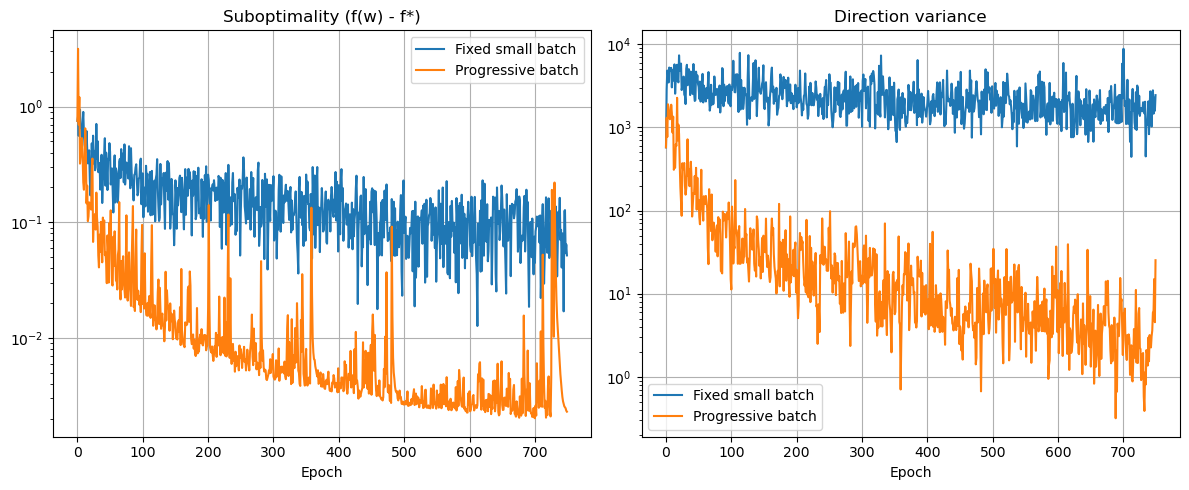

In [25]:
bs_start, bs_end = 16, 2048

hist_fixedC = run_sgd(
    X, y, lambda_reg=LAMBDA_REG,
    epochs=EPOCHS, batch_size=bs_start,
    lr0=lr0, scheduler=None,
    seed=0, f_opt=f_opt
)

hist_prog = run_sgd_progressive(
    X, y, lambda_reg=LAMBDA_REG,
    epochs=EPOCHS,
    bs_start=bs_start, bs_end=bs_end,
    lr0=lr0,
    seed=0, f_opt=f_opt
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.semilogy(hist_fixedC["epoch"], hist_fixedC["subopt"], label="Fixed small batch")
plt.semilogy(hist_prog["epoch"], hist_prog["subopt"], label="Progressive batch")
plt.title("Suboptimality (f(w) - f*)")
plt.xlabel("Epoch")
plt.grid(True); plt.legend()

plt.subplot(1,2,2)
plt.semilogy(hist_fixedC["epoch"], hist_fixedC["dir_var"], label="Fixed small batch")
plt.semilogy(hist_prog["epoch"], hist_prog["dir_var"], label="Progressive batch")
plt.title("Direction variance")
plt.xlabel("Epoch")
plt.grid(True); plt.legend()

plt.tight_layout()
plt.show()

### Questions 1.2:
1. Comparing the progressive batch strategy with fixed small batch, which approach reaches lower final suboptimality? Why might progressive batching help or hurt the direction variance in the early vs late phases?

2. Based on the obtained results, what is the main advantage of starting with small batches and increasing to large batches over simply using a fixed medium batch size throughout training?

1) En comparant les deux courbes de suboptimalité, la stratégie avec batch progressif atteint clairement une suboptimalité finale plus faible que le batch fixe petit, puisque sa courbe descend plus bas en fin d’entraînement. Cela s’explique par le fait qu’au début, utiliser de petits batchs permet de faire des mises à jour peu coûteuses et d’avancer rapidement, même si elles sont plus bruitées, alors qu’à la fin, l’augmentation progressive de la taille du batch réduit la variance de direction et rend les mises à jour plus stables. Autrement dit, dans la phase initiale, le progressive batching peut garder un peu de bruit, ce qui n’est pas forcément un problème, mais dans la phase finale il devient avantageux car il diminue fortement les oscillations et permet un affinement plus précis de la solution.
2) D’après les résultats obtenus, l’avantage principal de commencer avec de petits batchs puis d’augmenter progressivement vers de grands batchs est de combiner les avantages des deux régimes au cours de l’apprentissage. Au début, les petits batchs permettent des mises à jour moins coûteuses et une progression rapide, tandis qu’à la fin les grands batchs apportent une direction plus fiable et une variance plus faible, ce qui améliore la convergence finale. L’intérêt par rapport à un batch fixe moyen pendant tout l’entraînement est donc d’avoir une méthode plus adaptée aux différentes phases de l’optimisation, au lieu de garder en permanence un compromis unique qui n’est ni aussi rapide au début, ni aussi stable à la fin.

### Experiment 1.3:  Effect of the learning rate on the performance of SGD

Here we consider a fixed batch size and we study the effect of the learning rate, by dynamically decreasing it thanks to our polynomial scheduler.
We compare the scheduler with a constant learning-rate.

#### Polynomial learning rate scheduler

To reduce noise and improve convergence in later stages, we consider an adaptive learning rate strategy. We implement a polynomial decay schedule:

$$\alpha_k = \frac{\alpha_0}{(1 + \rho k)^p},$$

where $\alpha_0$ is the initial learning rate, $\rho$ controls the decay rate, $k$ is the epoch, and $p$ is the power (typically 1).

This schedule starts with a larger learning rate (step size) for exploration and gradually decreases it, allowing the optimizer to make fine adjustments near the optimum without overshooting.

In [26]:
def poly_scheduler(epoch, lr0, decay=5e-3, power=1.0):
    """Polynomial learning rate scheduler."""
    # Implement polynomial learning rate decay
    lr = lr0
    lr /= ((1 + decay * epoch) ** power)
    return lr

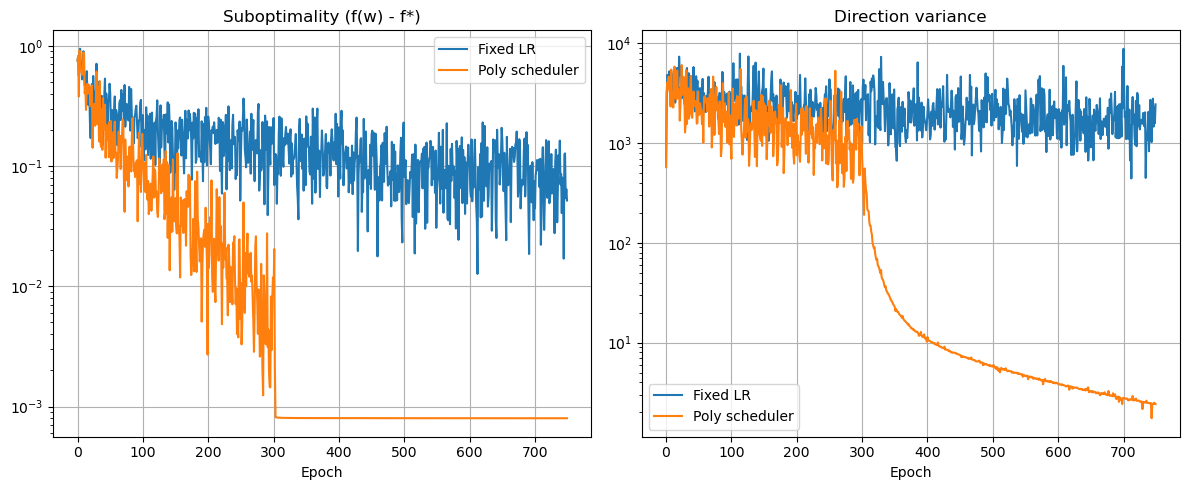

In [27]:
batch_size_fixed = 16

hist_fixed = run_sgd(
    X, y, lambda_reg=LAMBDA_REG,
    epochs=EPOCHS, batch_size=batch_size_fixed,
    lr0=lr0, scheduler=None,
    seed=0, f_opt=f_opt
)

hist_sched = run_sgd(
    X, y, lambda_reg=LAMBDA_REG,
    epochs=EPOCHS, batch_size=batch_size_fixed,
    lr0=lr0,
    scheduler=lambda ep, lr0: poly_scheduler(ep, lr0, decay=0.02),
    seed=0, f_opt=f_opt
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.semilogy(hist_fixed["epoch"], hist_fixed["subopt"], label="Fixed LR")
plt.semilogy(hist_sched["epoch"], hist_sched["subopt"], label="Poly scheduler")
plt.title("Suboptimality (f(w) - f*)")
plt.xlabel("Epoch")
plt.grid(True); plt.legend()

plt.subplot(1,2,2)
plt.semilogy(hist_fixed["epoch"], hist_fixed["dir_var"], label="Fixed LR")
plt.semilogy(hist_sched["epoch"], hist_sched["dir_var"], label="Poly scheduler")
plt.title("Direction variance")
plt.xlabel("Epoch")
plt.grid(True); plt.legend()

plt.tight_layout()
plt.show()

### Questions 1.3:
1. Compare the convergence behavior of fixed learning rate vs polynomial scheduler in Ex1.3. Explain why does decreasing the learning rate over time helps in the later stages of optimization?

2. How does the polynomial scheduler affect the direction variance as the algorithm progresses? Does the decreasing learning rate help stabilize or destabilize the gradient estimates?

1) On remarque que le polynomial scheduler converge mieux que le learning rate fixe, car sa courbe de suboptimalité descend beaucoup plus bas et devient presque plate à une valeur très faible un peu près 10<sup>-3</sup>, alors que celle du learning rate fixe reste plus haute et plus bruitée (à environ 10<sup>-1</sup>). Cela s’explique par le fait qu’au début, un learning rate relativement grand permet encore de progresser rapidement, mais plus on se rapproche de l’optimum, plus il devient utile de réduire la taille des pas pour éviter de dépasser le minimum ou d’osciller autour. En diminuant progressivement le learning rate, l’algorithme garde donc une bonne capacité de progression au début, puis devient plus précis dans la phase finale, ce qui améliore la convergence.
2) D’après la courbe de variance de direction, le polynomial scheduler réduit nettement la variance au fur et à mesure des epochs, alors qu’avec un learning rate fixe, la variance reste globalement élevée. Cela montre que la diminution du learning rate stabilise les mises à jour au cours de l’optimisation. En pratique, le gradient estimé reste bruité à cause du mini-batch, mais comme le pas appliqué à ce gradient devient plus petit, les directions de mise à jour deviennent moins instables et l’algorithme oscille moins. On peut donc dire que le learning rate décroissant ne rend pas l’estimation du gradient elle-même plus précise, mais il stabilise clairement les mises à jour produites par SGD.

## Exercise 2 – Variants of SGD and variance reduction methods
We now extend the basic SGD framework with additional stochastic optimization strategies.

### Exercise 2.1: Accelerated and Adaptive Stochastic Gradient Methods

The main limitation of basic gradient-type methods is their slow convergence, a behavior often attributed to the difficulty of selecting an appropriate learning rate (step size). To address this challenge, a wide range of accelerated and adaptive variants of stochastic gradient descent (SGD) have been developed.

We summarize here the update rules for the different methods that we will test. Let $g_k$ denote a (possibly stochastic) gradient evaluated at the current iterate $\theta_k$, and let $\alpha_k > 0$ denote the learning rate (step size).


#### SGD

$$
\theta_{k+1} = \theta_k - \alpha_k g_k.
$$


#### Nesterov Accelerated Gradient (NAG)

NAG computes the gradient at a look-ahead position and combines it with a momentum term.

Let $\beta \in (0,1)$ be the momentum parameter. The full update reads:

$$
\begin{aligned}
\tilde{\theta}_k &= \theta_k - \alpha_k \beta v_k 
\quad \text{(look-ahead position)}, \\
\tilde{g}_k &= \nabla f(\tilde{\theta}_k) 
\quad \text{(or stochastic estimate)}, \\
v_{k+1} &= \beta v_k + \tilde{g}_k, \\
\theta_{k+1} &= \theta_k - \alpha_k v_{k+1}.
\end{aligned}
$$


#### AdaGrad

AdaGrad updates the parameters $\theta$ at iteration $k$ in a component-wise manner:

$$
\theta_{k+1}(j)
= \theta_k(j)
- \frac{\alpha_k}{\sqrt{G_k(j) + \epsilon}} \, g_k(j),
\quad
G_k(j) = \sum_{l=1}^{k} g_l(j)^2.
$$

Here, the symbol $(j)$ denotes the $j$-th component of a vector, and $\epsilon > 0$ is a small constant added for numerical stability.


#### Adam

Adam combines adaptive learning rates with momentum by maintaining exponentially decaying averages of past gradients (first moment) and squared gradients (second moment):

\begin{align*}
m_k(j) &= \beta_1 m_{k-1}(j) + (1 - \beta_1) g_k(j),
\quad \beta_1 \in (0,1), \\
v_k(j) &= \beta_2 v_{k-1}(j) + (1 - \beta_2) \big(g_k(j)\big)^2,
\quad \beta_2 \in (0,1).
\end{align*}

These quantities are then bias-corrected as

\begin{align*}
\hat{m}_k(j) &= \frac{m_k(j)}{1 - \beta_1^k}, \\
\hat{v}_k(j) &= \frac{v_k(j)}{1 - \beta_2^k}.
\end{align*}

The parameters are updated in the following component-wise manner:

$$
\theta_{k+1}(j)
= \theta_k(j)
- \alpha_k \frac{\hat{m}_k(j)}{\sqrt{\hat{v}_k(j)} + \epsilon},
$$

where $\epsilon > 0$ is a small constant added for numerical stability.

All methods are applied to regularized logistic regression on an ill-conditioned synthetic dataset.

#### Construction of unified optimizer runner

We implement a single driver that supports multiple optimizers, tracks per-epoch loss, suboptimality, and direction variance and allows for fair comparison under identical conditions

In [28]:
def run_optimizer(
    X, y, lambda_reg=LAMBDA_REG,
    epochs=300, batch_size=16,
    optimizer="sgd",
    lr0=1e-3,
    beta=0.9,
    beta1=0.9, beta2=0.999,
    eps=1e-8,
    seed=0, f_opt=None
):

    n, d = X.shape
    rng = np.random.default_rng(seed)
    theta = np.zeros(d)

    # State variables
    v = np.zeros_like(theta)        # momentum velocity
    m = np.zeros_like(theta)        # first moment (Adam / AdaGrad)
    v_sq = np.zeros_like(theta)     # second moment (Adam)

    hist = {
        "epoch": [],
        "loss": [],
        "subopt": [],
        "dir_var": [],
        "optimizer": []
    }
    adam_t = 0
    for ep in range(epochs):
        idx = rng.permutation(n)
        Xs, ys = X[idx], y[idx]

        dirs = []   # store update directions within the epoch

        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            Xb, yb = Xs[start:end], ys[start:end]

            g = grad_logloss(theta, Xb, yb, lambda_reg)

            if optimizer == "sgd":
                # Implement SGD update
                d = zeros_like(theta, dtype=np.float64)
                d = -lr0 * g

            elif optimizer == "momentum":
                # Implement Momentum update
                d = zeros_like(theta, dtype=np.float64)
                v = beta * v + g
                d = -lr0 * v

            elif optimizer == "NAG":
                # Implement Nesterov Accelerated Gradient update
                d = zeros_like(theta, dtype=np.float64)
                theta_tilde = theta - lr0 * beta * v
                g_tilde = grad_logloss(theta_tilde, Xb, yb, lambda_reg)
                v = beta * v + g_tilde
                d = -lr0 * v

            elif optimizer == "adagrad":
                # Implement AdaGrad update
                d = zeros_like(theta, dtype=np.float64)
                m = m + g**2
                d = -(lr0 / np.sqrt(m + eps)) * g

            elif optimizer == "adam":
                # Implement Adam update
                d = zeros_like(theta, dtype=np.float64)
                adam_t += 1 
                m = beta1 * m + (1 - beta1) * g
                v_sq = beta2 * v_sq + (1 - beta2) * (g**2)
                m_chapeau = m / (1 - beta1**adam_t)
                v_chapeau = v_sq / (1 - beta2**adam_t)
                d = -lr0 * m_chapeau / (np.sqrt(v_chapeau) + eps)

            else:
                raise ValueError("Unknown optimizer")

            dirs.append(d)
            theta += d

        # Epoch-level statistics
        f = logloss(theta, X, y, lambda_reg)
        hist["epoch"].append(ep)
        hist["loss"].append(f)
        hist["subopt"].append(f - f_opt)
        hist["optimizer"].append(optimizer)


    return hist

### Comparison of different optimizers

We compare optimizers in the *full-batch* regime to isolate
the effect of update rules rather than sampling noise.

In [29]:
optimizers = ["sgd","momentum", "NAG", "adagrad", "adam"]
lr_rates = [1e-4, 1e-4, 1e-2, 1e-2, 1e-2]

histories = {}

for opt, lr in zip(optimizers, lr_rates):
    print(f"Running {opt} with lr={lr}")
    h = run_optimizer(
        X, y,
        epochs=EPOCHS,
        batch_size=X.shape[0],
        lr0=lr,
        optimizer=opt,
        f_opt=f_opt
    )
    histories[opt] = h

Running sgd with lr=0.0001
Running momentum with lr=0.0001
Running NAG with lr=0.01
Running adagrad with lr=0.01
Running adam with lr=0.01


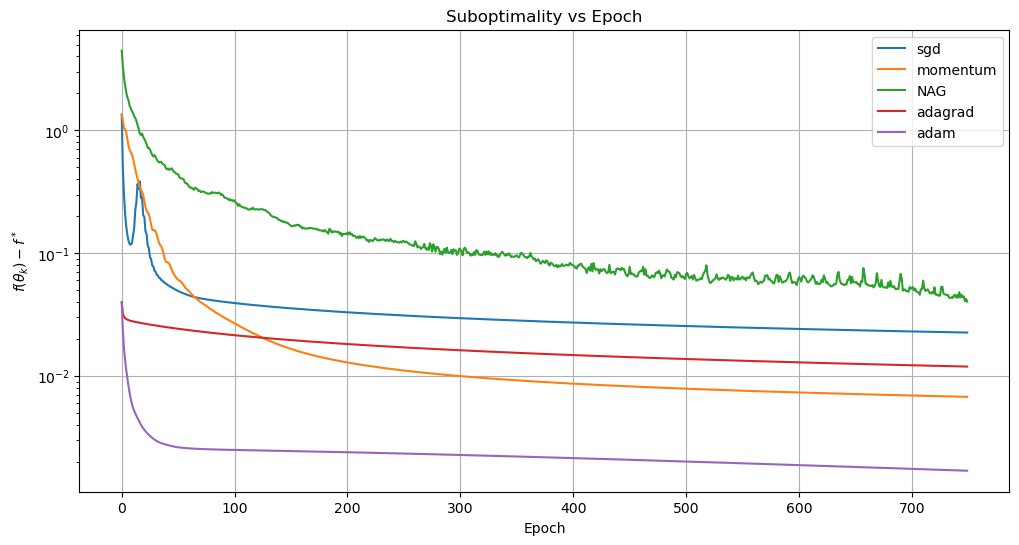

In [30]:
plt.figure(figsize=(12,6))

for opt in optimizers:
    h = histories[opt]
    plt.semilogy(h["epoch"], h["subopt"], label=opt)

plt.title("Suboptimality vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("$f(\\theta_k) - f^*$")
plt.grid(True)
plt.legend()
plt.show()

### Questions 2.1:
1. Rank the five optimizers (SGD, Momentum, NAG, AdaGrad, Adam) by their final convergence performance on the model problem. What key algorithm properties allow the top-performing methods to outperform SGD?

2. Are optimal learning rates same for all optimizers? What does this tell you about how adaptive methods respond to gradient scaling?

3. Consider the trade-off between convergence speed and computational complexity. Which optimizer would you recommend for this problem and why? Would your recommendation change if the problem dimension (d) was much larger?

4. Consider very large batch size. Does it makes sense in this case use adaptive optimizers?

1) D’après la courbe de suboptimalité finale, le classement semble être Adam > Momentum > AdaGrad > SGD > NAG. Adam est celui qui converge le plus et le plus vite, puis Momentum, ensuite AdaGrad, tandis que SGD reste plus haut et NAG est ici le moins bon. Ce qui permet aux meilleures méthodes de dépasser SGD, c’est surtout leur capacité à mieux exploiter l’information des gradients passés : Momentum et NAG utilisent une forme d’inertie qui accélère la descente dans les bonnes directions, et Adam ajoute en plus une adaptation du pas de mise à jour coordonnée par coordonnée. AdaGrad bénéficie aussi de cette adaptation.
2) Non, les learning rates optimaux ne sont pas les mêmes pour tous les optimiseurs, SGD et Momentum sont testés avec 10<sup>-4</sup>, alors que NAG, AdaGrad et Adam sont testés avec 10<sup>-2</sup>. Cela montre que chaque méthode réagit à la taille du pas. En particulier, les méthodes adaptatives comme AdaGrad et Adam supportent des learning rates initiaux plus grands parce qu’elles normalisent ou rééchelonnent les mises à jour selon l’historique des gradients, donc elles sont moins sensibles à une mauvaise homogénéité des composantes du gradient que SGD classique.
3) Si je prends en compte à la fois la vitesse de convergence et le coût de calcul, je recommanderais ici Adam, parce que c’est clairement celui qui atteint la plus faible suboptimalité et il le fait très rapidement. Son inconvénient est qu’il demande plus de mémoire et plus d’opérations par itération que SGD, puisqu’il faut stocker et mettre à jour les moments d’ordre 1 et 2. Si la dimension d devenait beaucoup plus grande, cette question deviendrait plus importante, car le coût mémoire de Adam et AdaGrad augmenterait fortement. Dans ce cas, on pourrait préférer Momentum, qui reste simple, peu coûteux, et offre déjà une amélioration nette par rapport à SGD tout en restant plus léger que les méthodes adaptatives.
4) Avec une très grande batch size, le bruit de gradient devient beaucoup plus faible, donc une partie de l’intérêt des optimiseurs adaptatifs diminue, car ils sont souvent particulièrement utiles quand les gradients sont bruités ou mal échelonnés. Dans ce cas, des méthodes plus simples comme SGD avec momentum peuvent devenir très compétitives, surtout si le learning rate est bien réglé. Cela dit, les méthodes adaptatives peuvent encore être utiles si le problème est mal conditionné. Donc ce n’est pas inutile par principe d’utiliser Adam ou AdaGrad avec un grand batch, mais leur avantage est généralement moins marqué que dans le régime stochastique avec petits mini-batchs.

### Exercise 2.2: Variance Reduction Techniques — SVRG and SAGA
Stochastic optimization involves a trade-off between:

- **Small batches**: low computational cost but high gradient noise (variance).
- **Large batches**: low variance but high computational cost.

Variance reduction techniques break this trade-off by constructing gradient estimators that have:

- Low variance (similar to full-batch gradients),
- Low computational cost (similar to small-batch gradients).

In this exercise, we compare three different approaches: SGD, SVRG, and SAGA.  
To this end, we explicitly assume that the objective function has the finite-sum structure

$$
f(\theta) = \frac{1}{n} \sum_{i=1}^n f_i(\theta),
$$

and write stochastic gradients as $\nabla f_{i_k}(\theta_k)$, where $i_k$ is a randomly sampled index (or a subset of indices in the mini-batch case).

#### 1. SGD (Baseline)

Standard stochastic gradient descent without variance reduction:

$$
\theta_{k+1}
=
\theta_k
-
\alpha_k
\nabla f_{i_k}(\theta_k).
$$


#### 2. SVRG (Stochastic Variance Reduced Gradient)

SVRG uses a **snapshot mechanism** for variance reduction.

At the beginning of each outer loop, a snapshot point $\theta_s$ is stored and the full gradient

$$
\tilde{g}_s = \nabla f(\theta_s)
$$

is computed.

The inner iteration update is then given as

$$
\theta_{k+1}
=
\theta_k
-
\alpha_k
\left(
\nabla f_{i_k}(\theta_k)
-
\nabla f_{i_k}(\theta_s)
+
\tilde{g}_s
\right).
$$


#### 3. SAGA (Stochastic Average Gradient)

SAGA uses a **stored gradient table** for variance reduction.

For each sample $i$, the algorithm maintains a reference point $\phi_i$ (initially, for example, $\phi_i = \theta_0$) and stores the corresponding gradient $\nabla f_i(\phi_i)$.

At iteration $k$, after sampling index $i_k$, the update is

$$
\theta_{k+1}
=
\theta_k
-
\alpha_k
\left(
\nabla f_{i_k}(\theta_k)
-
\nabla f_{i_k}(\phi_{i_k})
+
\frac{1}{n}
\sum_{j=1}^{n}
\nabla f_j(\phi_j)
\right).
$$

The update consists of three components:

- $\nabla f_{i_k}(\theta_k)$: the current stochastic gradient.
- $-\nabla f_{i_k}(\phi_{i_k})$: a correction term that removes the previously stored gradient for the same sample.
- $\frac{1}{n}\sum_{j=1}^{n}\nabla f_j(\phi_j)$: the average of all stored gradients, which serves as an incremental approximation of the full gradient.

Intuitively, SAGA replaces the noisy stochastic gradient with a corrected estimator: it subtracts outdated information for the sampled index and adds back a global gradient estimate built from all stored gradients.

Taking the expectation with respect to $i_k$, one can verify that this estimator is unbiased:

$$
\mathbb{E}_{i_k}
\left[
\nabla f_{i_k}(\theta_k)
-
\nabla f_{i_k}(\phi_{i_k})
+
\frac{1}{n}
\sum_{j=1}^{n}
\nabla f_j(\phi_j)
\right]
=
\nabla f(\theta_k).
$$

However, its variance is significantly smaller than that of the plain stochastic gradient $\nabla f_{i_k}(\theta_k)$, especially as the stored reference points $\phi_j$ approach $\theta_k$.

After the update, the stored reference point is refreshed:

$$
\phi_{i_k} \leftarrow \theta_k.
$$

Unlike SVRG, SAGA does not require a separate snapshot phase; instead, it maintains an incremental estimate of the full gradient.

In [31]:
# ============================================================================
# VARIANCE-REDUCED GRADIENT METHODS
# ============================================================================

def run_svrg(X, y, lambda_reg=1e-4, num_passes=10, batch_size=4, lr0=1e-3, seed=0, f_opt=None):
    """
    Stochastic Variance Reduced Gradient (SVRG) optimizer.
    Uses snapshot mechanism for variance reduction.
    """
    n, d = X.shape
    rng = np.random.default_rng(seed)
    theta = np.zeros(d)
    
    hist_loss, hist_grad_evals, hist_subopt = [], [], []
    grad_evals = 0
    
    for pass_num in range(num_passes):
        # Snapshot phase
        theta_snapshot = theta.copy()
        grad_snapshot = grad_logloss(theta_snapshot, X, y, lambda_reg)
        grad_evals += n
        
        # Inner loop
        idx = rng.permutation(n)
        Xs, ys = X[idx], y[idx]
        
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            Xb, yb = Xs[start:end], ys[start:end]
            
            # Implement SVRG update using current gradient, snapshot gradient, and variance reduction
            dir_svrg = zeros_like(theta, dtype=np.float64)
            dir_svrg = grad_logloss(theta, Xb, yb, lambda_reg) - grad_logloss(theta_snapshot, Xb, yb, lambda_reg) + grad_snapshot
            grad_evals += 2 * batch_size
            theta = theta + (-lr0 * dir_svrg)
        
        f = logloss(theta, X, y, lambda_reg)
        hist_loss.append(f)
        hist_subopt.append(f - f_opt)
        hist_grad_evals.append(grad_evals)
    
    return {
        "loss": np.array(hist_loss),
        "subopt": np.array(hist_subopt),
        "grad_evals": np.array(hist_grad_evals)
    }

def run_saga(X, y, lambda_reg=1e-4, num_passes=10, batch_size=4, lr0=1e-3, seed=0, f_opt=None):
    """
    SAGA (Stochastic Average Gradient - A) optimizer.
    Uses stored gradient history for variance reduction.
    """
    n, d = X.shape
    rng = np.random.default_rng(seed)
    theta = np.zeros(d)
    
    # Store one gradient per sample
    grad_table = np.zeros((n, d))
    for i in range(n):
        grad_table[i] = grad_logloss(theta, X[i:i+1], y[i:i+1], lambda_reg)
    
    hist_loss, hist_grad_evals, hist_subopt = [], [], []
    grad_evals = n  # Initial full pass to fill table
    
    mean_grad = np.mean(grad_table, axis=0)
    for pass_num in range(num_passes):
        idx = rng.permutation(n)
        
        for sample_idx in idx:
            # Compute new gradient for this sample
            grad_new = grad_logloss(theta, X[sample_idx:sample_idx+1], y[sample_idx:sample_idx+1], lambda_reg)
            
            # Implement SAGA update using grad_saga
            dir_saga = zeros_like(theta, dtype=np.float64)
            dir_saga = grad_new - grad_table[sample_idx] + mean_grad
            
            theta = theta + (-lr0 * dir_saga)
            
            mean_grad = mean_grad + (grad_new - grad_table[sample_idx]) / n
            grad_table[sample_idx] = grad_new

            grad_evals += 1  # One for new gradient, one for accessing table
        
        # Track loss every pass
        f = logloss(theta, X, y, lambda_reg)
        hist_loss.append(f)
        hist_subopt.append(f - f_opt)
        hist_grad_evals.append(grad_evals)
    
    return {
        "loss": np.array(hist_loss),
        "subopt": np.array(hist_subopt),
        "grad_evals": np.array(hist_grad_evals)
    }

def run_sgd_fair(X, y, lambda_reg=1e-4, num_passes=10, batch_size=4, lr0=1e-3, seed=0, f_opt=None):
    """
    SGD with gradient budget tracking (for fair comparison).
    """
    n, d = X.shape
    rng = np.random.default_rng(seed)
    theta = np.zeros(d)
    
    hist_loss, hist_grad_evals, hist_subopt = [], [], []
    grad_evals = 0
    
    for pass_num in range(num_passes):
        idx = rng.permutation(n)
        Xs, ys = X[idx], y[idx]
        
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            Xb, yb = Xs[start:end], ys[start:end]
            
            grad_batch = grad_logloss(theta, Xb, yb, lambda_reg)
            grad_evals += batch_size
            
            theta = theta + (-lr0 * grad_batch)
        
        f = logloss(theta, X, y, lambda_reg)
        hist_loss.append(f)
        hist_subopt.append(f - f_opt)
        hist_grad_evals.append(grad_evals)
    
    return {
        "loss": np.array(hist_loss),
        "subopt": np.array(hist_subopt),
        "grad_evals": np.array(hist_grad_evals)
    }

### Learning Rate Tuning

Find optimal learning rates for each method. Different algorithms benefit from different learning rates due to their variance properties.

In [32]:
# Learning rate tuning for all three methods
print("=" * 80)
print("EX3.0: Learning Rate Tuning")
print("=" * 80)

lr_values = [1e-6, 5e-6, 1e-5, 5e-5, 1e-4]
print(f"\nTesting learning rates: {lr_values}")
print("Using batch_size=4, 10 passes")

best_lr_svrg = None
best_lr_saga = None
best_lr_sgd = None
best_loss_svrg = float('inf')
best_loss_saga = float('inf')
best_loss_sgd = float('inf')

for lr in lr_values:
    res_svrg = run_svrg(X, y, num_passes=10, batch_size=4, lr0=lr, f_opt=f_opt)
    res_saga = run_saga(X, y, num_passes=10, batch_size=4, lr0=lr, f_opt=f_opt)
    res_sgd = run_sgd_fair(X, y, num_passes=10, batch_size=4, lr0=lr, f_opt=f_opt)
    
    final_svrg = res_svrg['subopt'][-1]
    final_saga = res_saga['subopt'][-1]
    final_sgd = res_sgd['subopt'][-1]
    
    if final_svrg < best_loss_svrg:
        best_loss_svrg = final_svrg
        best_lr_svrg = lr
    if final_saga < best_loss_saga:
        best_loss_saga = final_saga
        best_lr_saga = lr
    if final_sgd < best_loss_sgd:
        best_loss_sgd = final_sgd
        best_lr_sgd = lr
    
    print(f"\nlr={lr:.0e}:")
    print(f"  SVRG final: {final_svrg:.6e}")
    print(f"  SAGA final: {final_saga:.6e}")
    print(f"  SGD final:  {final_sgd:.6e}")

print(f"\n✓ Optimal learning rates found:")
print(f"  SVRG: {best_lr_svrg:.0e}")
print(f"  SAGA: {best_lr_saga:.0e}")
print(f"  SGD:  {best_lr_sgd:.0e}")

EX3.0: Learning Rate Tuning

Testing learning rates: [1e-06, 5e-06, 1e-05, 5e-05, 0.0001]
Using batch_size=4, 10 passes

lr=1e-06:
  SVRG final: 4.559683e-02
  SAGA final: 3.249292e-02
  SGD final:  4.731849e-02

lr=5e-06:
  SVRG final: 2.227934e-02
  SAGA final: 8.381720e-02
  SGD final:  4.663741e-02

lr=1e-05:
  SVRG final: 3.347495e-02
  SAGA final: 5.190070e-01
  SGD final:  7.439525e-02

lr=5e-05:
  SVRG final: 1.492906e-01
  SAGA final: 8.097693e-01
  SGD final:  2.792894e-01

lr=1e-04:
  SVRG final: 3.497663e-01
  SAGA final: 7.255846e-01
  SGD final:  7.977353e-01

✓ Optimal learning rates found:
  SVRG: 5e-06
  SAGA: 1e-06
  SGD:  5e-06


#### Fair Comparison with Equal Gradient Budget

Variance reduction methods are more costly per epoch as SGD:
- **SVRG per epoch**: 1 snapshot + n/batch_size inner gradients ≈ 2× more work than SGD
- **SAGA per epoch**: Similar structure to SGD but with stored gradient overhead
- **SGD per epoch**: n/batch_size gradients (baseline)

Thus, we perform comparison using **gradient evaluation count**, not epoch count, to ensure fairness.

In [33]:
# Ex3.1: Fair comparison with optimal learning rates
print("\n" + "=" * 80)
print("EX3.1: FAIR COMPARISON - SVRG vs SAGA vs SGD")
print("=" * 80)
print("\nUsing optimal learning rates from Ex3.0")
print(f"batch_size=4, 100 passes")

# Run all three optimizers with optimal learning rates
result_svrg_ex3 = run_svrg(X, y, num_passes=100, batch_size=4, 
                            lr0=best_lr_svrg, f_opt=f_opt)
result_saga_ex3 = run_saga(X, y, num_passes=100, batch_size=4, 
                            lr0=best_lr_saga, f_opt=f_opt)
result_sgd_ex3 = run_sgd_fair(X, y, num_passes=100, batch_size=4, 
                               lr0=best_lr_sgd, f_opt=f_opt)


EX3.1: FAIR COMPARISON - SVRG vs SAGA vs SGD

Using optimal learning rates from Ex3.0
batch_size=4, 100 passes


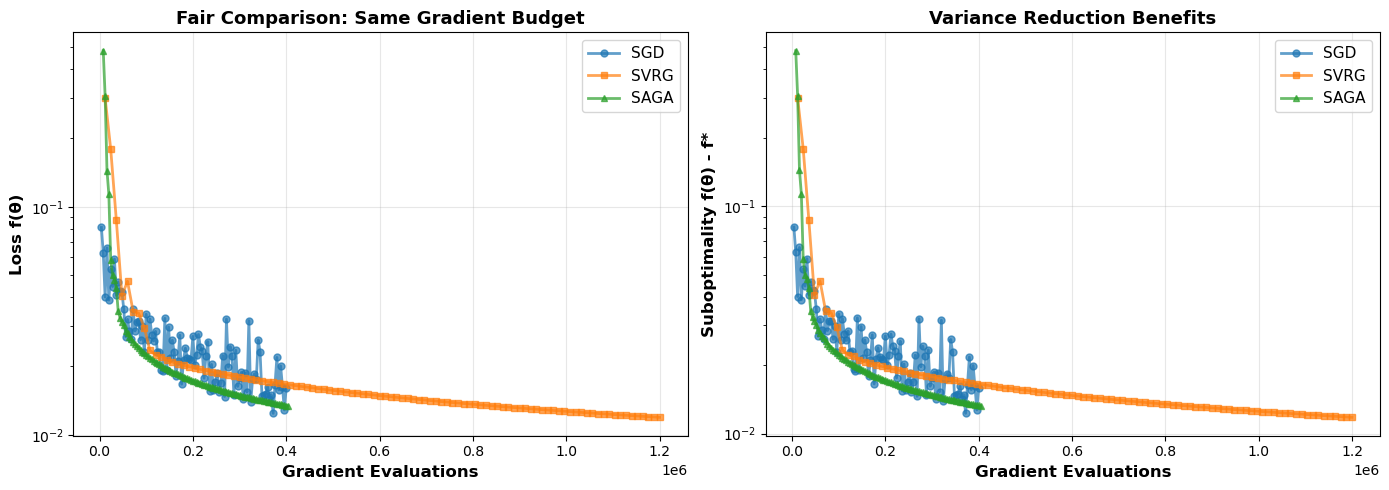

In [34]:
# Visualization: Fair comparison with gradient budget
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss vs gradient evaluations
ax = axes[0]
ax.semilogy(result_sgd_ex3['grad_evals'], result_sgd_ex3['loss'], 'o-', 
            label='SGD', linewidth=2, markersize=5, alpha=0.7, color='#1f77b4')
ax.semilogy(result_svrg_ex3['grad_evals'], result_svrg_ex3['loss'], 's-', 
            label='SVRG', linewidth=2, markersize=5, alpha=0.7, color='#ff7f0e')
ax.semilogy(result_saga_ex3['grad_evals'], result_saga_ex3['loss'], '^-', 
            label='SAGA', linewidth=2, markersize=5, alpha=0.7, color='#2ca02c')
ax.set_xlabel('Gradient Evaluations', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss f(θ)', fontsize=12, fontweight='bold')
ax.set_title('Fair Comparison: Same Gradient Budget', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)

# Plot 2: Suboptimality vs gradient evaluations
ax = axes[1]
ax.semilogy(result_sgd_ex3['grad_evals'], result_sgd_ex3['subopt'], 'o-', 
            label='SGD', linewidth=2, markersize=5, alpha=0.7, color='#1f77b4')
ax.semilogy(result_svrg_ex3['grad_evals'], result_svrg_ex3['subopt'], 's-', 
            label='SVRG', linewidth=2, markersize=5, alpha=0.7, color='#ff7f0e')
ax.semilogy(result_saga_ex3['grad_evals'], result_saga_ex3['subopt'], '^-', 
            label='SAGA', linewidth=2, markersize=5, alpha=0.7, color='#2ca02c')
ax.set_xlabel('Gradient Evaluations', fontsize=12, fontweight='bold')
ax.set_ylabel('Suboptimality f(θ) - f*', fontsize=12, fontweight='bold')
ax.set_title('Variance Reduction Benefits', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Questions 2.2:

1. Compare the three methods (SGD, SVRG, SAGA). Which method achieves the lowest loss per gradient evaluation and why? Discuss the roles of variance reduction, snapshot/table overhead, and batch size in explaining their relative performance.

2. Explain the extra computational costs behind SVRG and SAGA (full-gradient snapshot in SVRG, gradient-table maintenance in SAGA). How do these overheads trade off against variance reduction when the batch size or dataset size changes?

3. Discuss learning-rate sensitivity for each method. Which method(s) need more careful tuning and why? 

4. For which problem regimes (e.g., very high gradient variance, very large n, limited memory) would you recommend using SVRG or SAGA instead of plain SGD? Give concrete trade-offs and limitations for each recommendation.


1) D'après les courbes qu'on a obtenu, SAGA atteint la perte la plus basse par évaluation de gradient, suivi de SVRG, puis SGD. Cela s'explique par la réduction de variance. SGD évalue le gradient sur un mini-batch aléatoire avec variance élevée, tandis que SVRG construit $\tilde{g}_l = \nabla f_{j_l}(\tilde{x}_l) - \nabla f_{j_l}(x_k) + \nabla R_N(x_k)$ pour réduire la variance via le snapshot. SAGA maintient une table de gradients et utilise $g_k = \nabla f_l(x_k) - \nabla f_l(x^{[l]}) + \frac{1}{N}\sum_{j=1}^N \nabla f_j(x^{[j]})$, ce qui donne aussi une variance réduite sans surcoût de snapshot. SAGA surpasse SVRG car il n'a pas d'étape de snapshot global coûteux à chaque cycle. Bien que les deux offrent une réduction de variance similaire, SAGA amortit mieux son coût. Avec un petit batch (batch_size=4), cette réduction de variance devient cruciale et compense les coûts additionnels par rapport à SGD simple.

2) SVRG ajoute deux surcoûts : le snapshot gradient qui coûte $n$ évaluations à chaque cycle, et une structure globale d'environ 2× le coût d'une passe SGD. SAGA comporte une table de gradients (coût mémoire $O(N \times d)$) mais chaque itération ne coûte qu'une évaluation de gradient, similaire à SGD après initialisation. Lorsque le batch est petit, la variance domine et les surcoûts sont amortis rapidement. Cependant, pour un dataset très volumineux, le snapshot de SVRG devient prohibitif et la table de SAGA consomme trop de mémoire. Dans ces régimes, SGD simple avec batch croissant redevient compétitif car la variance naturelle baisse avec la taille du batch.

3) Les taux d'apprentissage optimaux trouvés expérimentalement sont SVRG = 5e-6, SAGA = 1e-6 et SGD = 1e-5. SVRG et SAGA exigent des taux plus faibles car leurs directions de descente sont déjà précises grâce à la réduction de variance, un taux trop élevé risque de faire dépasser l'optimum même en suivant une bonne direction. SAGA est particulièrement sensible car sa table se construit graduellement. Pendant la phase initiale où la table est encore partiellement obsolète, un taux d'apprentissage trop élevé entraîne $\theta$ dans de mauvaises directions qui viennent ensuite polluer la table et déstabilisent la convergence. SGD tolère au contraire un taux plus élevé pour compenser le bruit important de ses directions de descente, un taux trop faible ralentirait drastiquement sa progression.

4) Pour une variance élevée, on recommande SVRG en priorité. Son snapshot se met à jour à chaque passe, donc la correction du bruit est immédiatement efficace, contrairement à SAGA qui doit accumuler l'historique sur plusieurs itérations avant de vraiment réduire la variance. Le surcoût de calcul se justifie ici car la réduction de variance accélère fortement la convergence. Pour un très grand dataset, on recommande SAGA, car le snapshot de SVRG devient trop coûteux à recalculer constamment. SAGA évite ce problème en mettant à jour la table progressivement, mais il faut faire attention à sa mémoire $O(N \times d)$ qui devient problématique. SGD reste une alternative viable avec un bon scheduler (comme nous avons pu l'expérimenter plus haut), d'autant plus que la variance naturelle baisse avec des batchs plus grands. Pour une mémoire limitée, on recommande SVRG, car il ne stocke qu'un vecteur de taille $d$ (le snapshot) contrairement à SAGA qui demande $N \times d$. Si la mémoire est vraiment critique, SGD est le seul choix viable : aucun surcoût mémoire, mais convergence plus lente.